### Imports ###

#### Demographic Information
*   **`Gender`**: Gender of the individual 
*   **`Age`**: Age of the individual in years 
*   **`Height`**: Height of the individual in meters 
*   **`Weight`**: Weight of the individual in kilograms 

#### Eating Habits
*   **`family_history_with_overweight`**: Has a family member suffered or suffers from overweight? 
*   **`FAVC`**: Do you eat high caloric food frequently? 
*   **`FCVC`**: Do you usually eat vegetables in your meals? 
*   **`NCP`**: How many main meals do you have daily? 
*   **`CAEC`**: Do you eat any food between meals? 
*   **`CH2O`**: How much water do you drink daily? 
*   **`CALC`**: How often do you drink alcohol? 

#### Physical Condition & Lifestyle
*   **`SMOKE`**: Do you smoke? 
*   **`SCC`**: Do you monitor the calories you eat daily? 
*   **`FAF`**: How often do you have physical activity? 
*   **`TUE`**: How much time do you use technological devices daily? 
*   **`MTRANS`**: What transportation do you usually use? 
---
#### Target Variable
*   **`NObeyesdad`** (or **`NObesity`**): 
    *   `Insufficient Weight`
    *   `Normal Weight`
    *   `Overweight Level I`
    *   `Overweight Level II`
    *   `Obesity Type I`
    *   `Obesity Type II`
    *   `Obesity Type III`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("dataset.csv")
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
df.shape

(2111, 17)

In [8]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

### Feature Engineering

In [11]:
# Convert kg to lbs
df['Weight_lbs'] = df['Weight'] * 2.20462   

In [12]:
# Convert meters to inches
df['Height_in'] = df['Height'] * 39.3701

In [15]:
# Calculate BMI and round to 1 decimal place
df['BMI'] = (df['Weight_lbs'] / (df['Height_in'] ** 2)) * 703
df['BMI'] = df['BMI'].round(1)

In [22]:
# Drop the height and weight columns
df = df.drop(columns=['Height', 'Weight'])

In [24]:
df.rename(columns={'NObeyesdad': 'Target'})

,Gender,Age,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Target,weight_lbs,Weight_lbs,Height_in,BMI
0,Female,21.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight,141.095680,141.095680,63.779562,24.4
1,Female,21.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight,123.458720,123.458720,59.842552,24.2
2,Male,23.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight,169.755740,169.755740,70.866180,23.8
3,Male,27.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I,191.801940,191.801940,70.866180,26.8
4,Male,22.000000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II,197.974876,197.974876,70.078778,28.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III,289.705869,289.705869,67.351611,44.9
2107,Female,21.982942,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III,294.852367,294.852367,68.841927,43.7
2108,Female,22.524036,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III,294.734219,294.734219,68.984525,43.5
2109,Female,24.361936,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III,293.978672,293.978672,68.482320,44.1


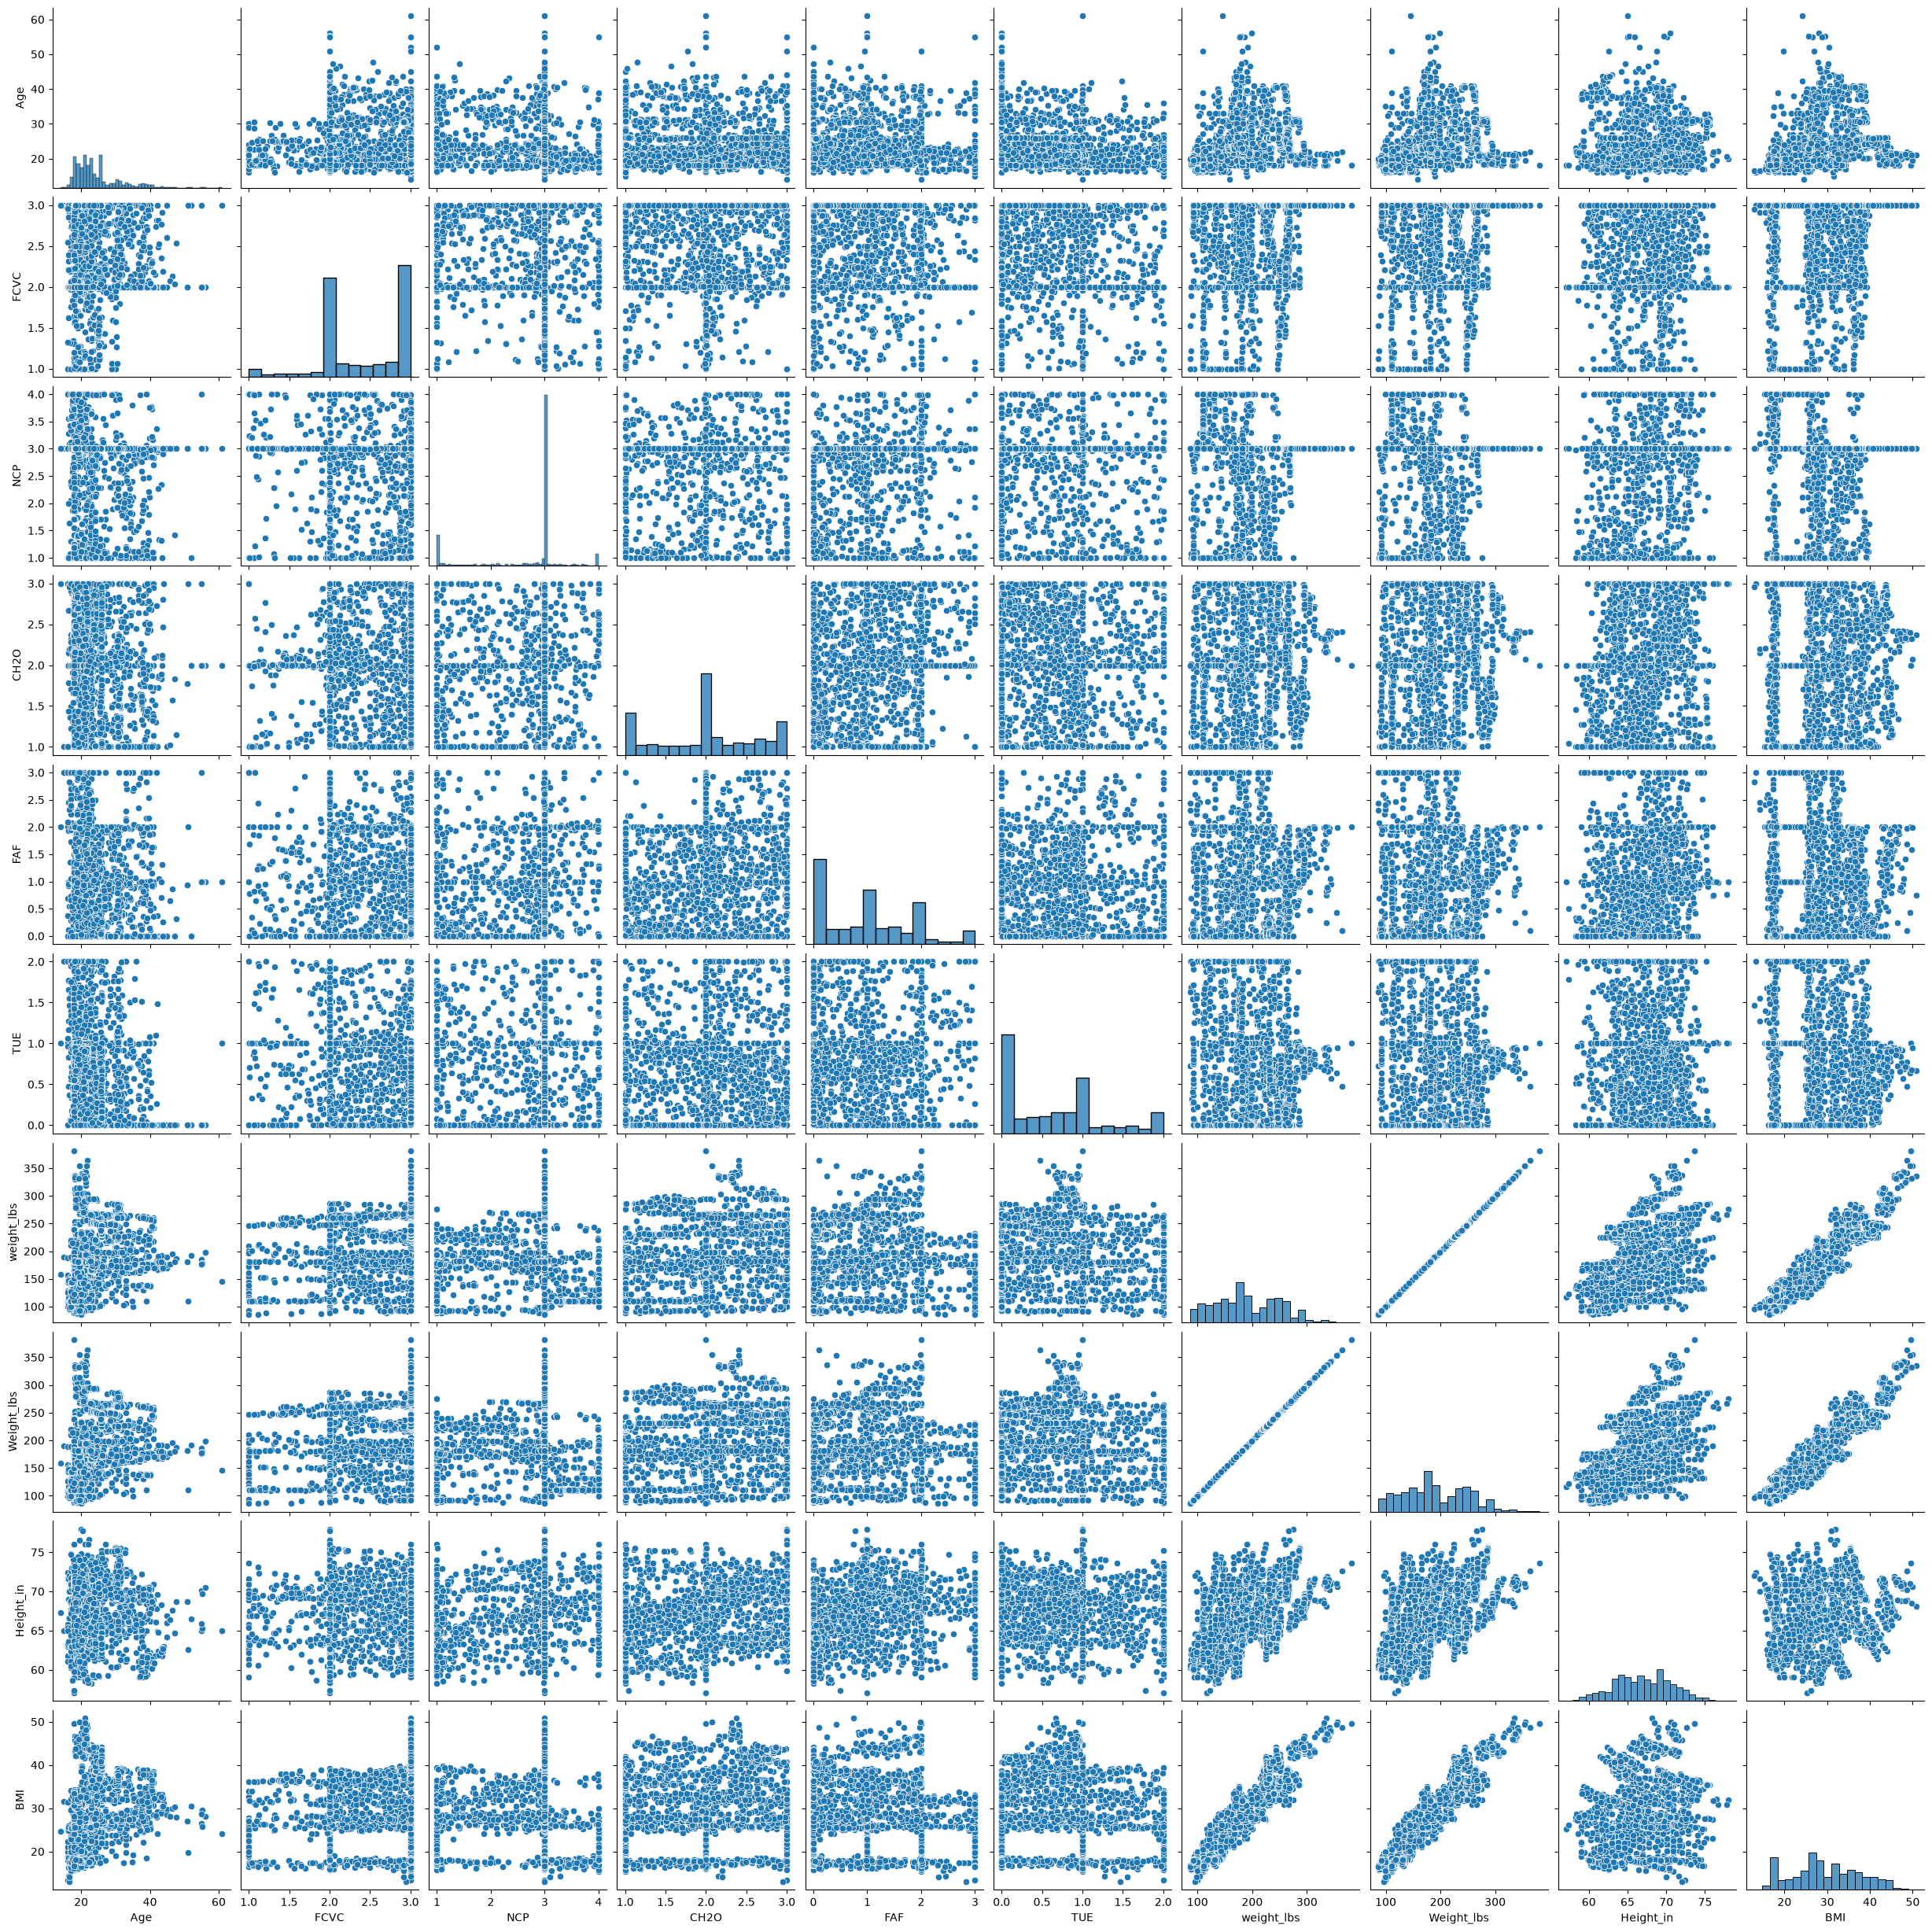

In [26]:
sns.pairplot(df)